In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os

import sde_lib
import datasets

import matplotlib.pyplot as plt
from models import ddpm as ddpm_model
from models import utils as mutils
from configs.vp import AI4Scup2_ddpm_continuous as configs

from utils_cbs import plot2Dimage, RelL2Loss

In [2]:
config = configs.get_config()

config.device_ids = [0,1,2,3]
config.device = torch.device('cuda:' + str(config.device_ids[0])) if torch.cuda.is_available() else torch.device('cpu')

In [10]:
score_model_path = "/home/caoxiang/Desktop/diffusion_model/score_sde_pytorch_training/workdir/AI4Scup2/256/checkpoints/checkpoint_25.pth"

score_model = ddpm_model.DDPM(config)
score_model = torch.nn.DataParallel(score_model, config.device_ids)
score_model = score_model.cuda(device=config.device_ids[0])

# Resume training when intermediate checkpoints are detected; 
loaded_state = torch.load(score_model_path, map_location=config.device)
score_model.load_state_dict(loaded_state['model'], strict=False)

# Define the diffusion process SDE
sde = sde_lib.VPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, N=config.model.num_scales)
score_fn = mutils.get_score_fn(sde, score_model, train=False, continuous=config.training.continuous)
sampling_eps = 1e-4

In [12]:
config.eval.batch_size = 1
train_dataset, train_loader, eval_dataset, eval_loader = datasets.get_dataset_pytorch(config)

scaler = datasets.get_data_scaler(config)
inverse_scaler = datasets.get_data_inverse_scaler(config)

In [13]:
def normalize(x, x_max = 1595.1279, x_min = 1408.692):
        x = F.interpolate(x[:,:,90:390,90:390], size=(256, 256), mode='bilinear', align_corners=False)
        return 2 * (x - x_min)/(x_max - x_min) - 1

def denormalize(x, x_max = 1595.1279, x_min = 1408.692):
        x = F.interpolate(x, size=(300, 300), mode='bilinear', align_corners=False)
        x = (x + 1) * (x_max - x_min) / 2 + x_min
        return F.pad(x, (90, 90, 90, 90), mode='constant', value= 1500)

def score_denormalize(pred_out, x_max = 1595.1279, x_min = 1408.692):
    return (x_max - x_min) * (pred_out + torch.tensor(1., device= pred_out.device)) / 2 + x_min
    
def score_normalize(pred_out, x_max = 1595.1279, x_min = 1408.692):
    return 2 * (pred_out - x_min)/(x_max - x_min) - torch.tensor(1., device= pred_out.device)


#装载图片
def log_image(path, field, pred_field, min_output=1408.692, max_output=1595.1279):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 用于确保统一的colorbar范围
    vmin, vmax = min_output, max_output

    # 显示第一个图像 field
    im1 = axes[0].imshow(field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("Field")
    fig.colorbar(im1, ax=axes[0])

    # 显示第二个图像 pred_field
    im2 = axes[1].imshow(pred_field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("Free Predicted field")
    fig.colorbar(im2, ax=axes[1])

    im3 = axes[2].imshow(pred_field[1, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("10db Predicted Field")
    fig.colorbar(im3, ax=axes[2])

    im4 = axes[3].imshow(pred_field[2, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[3].set_title("5db Predicted Field")
    fig.colorbar(im4, ax=axes[3])

    # 调整布局并保存图像
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()

In [15]:
count = 300
speed_batch, speed_5db_NIO_batch, speed_10db_NIO_batch, speed_free_NIO_batch = eval_dataset.__getitem__(count)

speed_batch = scaler(speed_batch.cuda(device=config.device_ids[0])).unsqueeze(0)
speed_free_NIO_batch = scaler(speed_free_NIO_batch.cuda(device=config.device_ids[0])).unsqueeze(0)
speed_10db_NIO_batch = scaler(speed_10db_NIO_batch.cuda(device=config.device_ids[0])).unsqueeze(0)
speed_5db_NIO_batch = scaler(speed_5db_NIO_batch.cuda(device=config.device_ids[0])).unsqueeze(0)

speed_NIO_batch = torch.cat([speed_free_NIO_batch, speed_10db_NIO_batch, speed_5db_NIO_batch], dim=0)

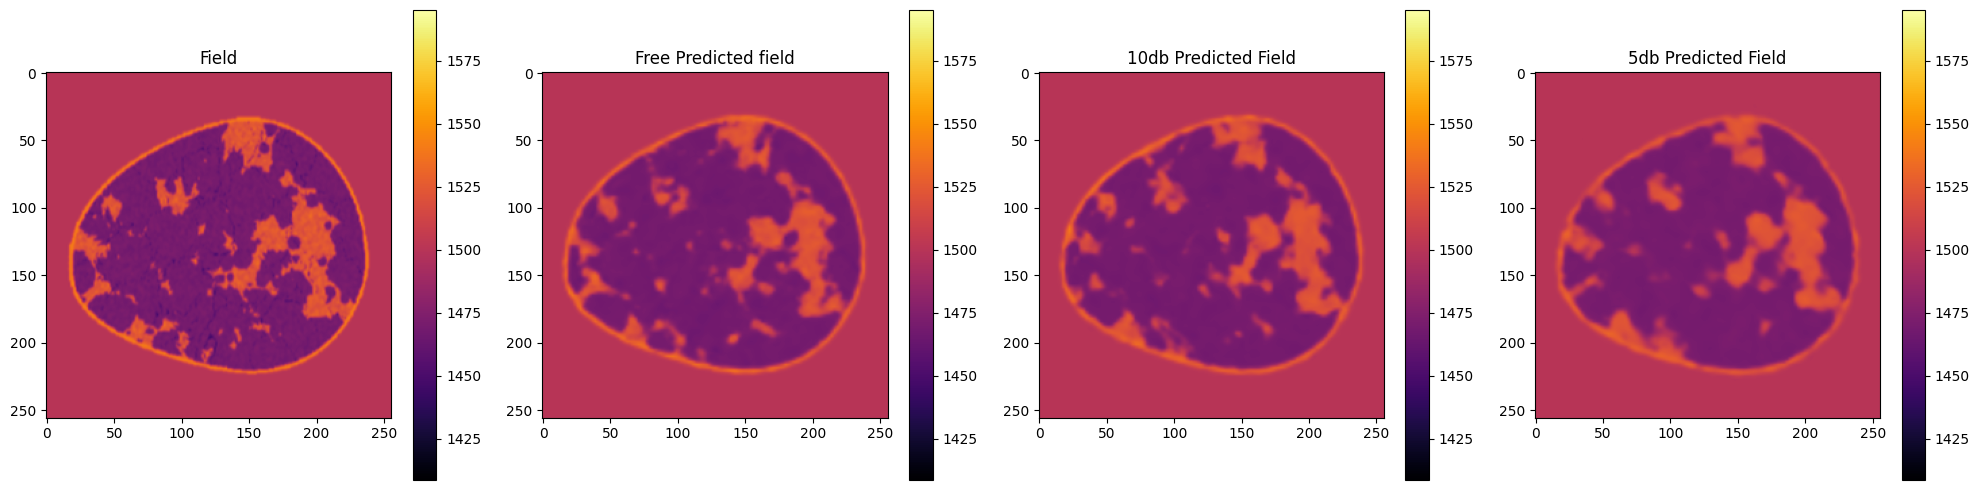

In [16]:
speed_NIO_batch_plot = score_denormalize(speed_NIO_batch).detach().cpu().numpy()
speed_batch_plot = score_denormalize(speed_batch).detach().cpu().numpy()

log_image("test_debug.png", speed_batch_plot, speed_NIO_batch_plot)

In [17]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

x_pos = loadmat('x_pos.mat')['x_pos256']
y_pos = loadmat('y_pos.mat')['y_pos256']

x_pos_down = x_pos[2::4]
y_pos_down = y_pos[2::4]

receiver_indices = torch.cat((torch.tensor(x_pos.astype(np.int64)), torch.tensor(y_pos.astype(np.int64))), dim = 1)
transmitter_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)

In [18]:
# sos  = denormalize(speed_batch)[0,0].detach().cpu()/1500
# inv_sos2 = 1/sos**2
# inv_sos2_center = (torch.max(inv_sos2) + torch.min(inv_sos2))/2

# new_N = torch.tensor([512,512])
# roi_size = torch.tensor([480,480])
# Bl = torch.ceil((new_N- roi_size)/2).to(int)
# Br = torch.floor((new_N - roi_size)/2).to(int)
# roi = [[Bl[0],Bl[0]+roi_size[0]],[Bl[1],Bl[1]+roi_size[1]]]

# inv_sos2_pad = F.pad(inv_sos2.unsqueeze(0), (Bl[1], Br[1], Bl[0], Br[0]), mode='replicate').squeeze()

# # add boundary
# Bmax = torch.max(Br)
# k0 = torch.sqrt(torch.mean(inv_sos2_pad))*2*torch.pi/(4)# k0 in 1/pixels

# c = 1 * k0**2 / (2*k0)
# x = torch.cat((torch.arange(Bl[0], 0, -1), torch.zeros(roi_size[0]), torch.arange(1, Br[0] + 1))).view(-1,1)
# y = torch.cat((torch.arange(Bl[1], 0, -1), torch.zeros(roi_size[1]), torch.arange(1, Br[1] + 1)))
# dist = torch.sqrt(x**2 + y**2)

# r = dist

# f_boundary_curve = 1 / k0**2 * (c**7 * r**5 * (6.0 + (2.0j * k0 - c) * r)) / \
#                 (720 + 720 * c * r + 360 * c**2 * r**2 + 120 * c**3 * r**3 + 30 * c**4 * r**4 + 6 * c**5 * r**5 + c**6 * r**6)
# plt.imshow(np.abs(f_boundary_curve))

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvergentBornSeries(nn.Module):
    def __init__(self,
                 lamb = 1,
                 sos=None,
                 src_loc=[30,60],
                 boundary_width=[8,8],
                 boundary_strength=1,
                 boundary_type='PML3',
                 device = "cuda:0",
                 ):
        super().__init__()
        # Device
        self.device = device
        # # PDE params
        self.lamb = lamb
        self.omega0 = 2*torch.pi / self.lamb 
        
        # Discretization
        self.PPW = 4
        self.pixel_size = self.lamb / self.PPW 
        
        self.sos = nn.Parameter(sos, requires_grad = True).to(device)
        self.N = torch.tensor(sos.size()).to(int)
        
        # Sources Location
        self.src = torch.zeros_like(self.sos)
        self.src[src_loc[0],src_loc[1]] = 1.
        self.src = nn.Parameter(self.src, requires_grad = False)
        
        # Boundary Padding
        self.boundary_widths = torch.tensor(boundary_width,dtype=int)
        self.boundary_strength = boundary_strength
        self.boundary_type = boundary_type
        self.set_grid()
        
        # V(x) Params
        self.k =  self.omega0/self.sos
        self.k0 = torch.sqrt((torch.max(self.k**2) + torch.min(self.k**2))/2).detach()
        
        # CBS Iteration Params
        self.k2_pad = self.set_boundary(self.k)
        self.epsilon = torch.max(torch.abs(self.k2_pad**2 - self.k0**2)).detach()
        self.g0 = 1/(self.px_range**2+self.py_range**2-self.k0**2 - 1.0j*self.epsilon).detach()
        
        self.V = self.k2_pad - self.k0**2 - 1.0j*self.epsilon
        self.gamma = 1.j/self.epsilon*self.V
    
    def forward(self,max_iters=5,tol=1e-16, requries_grad = False):
        self.u = torch.zeros(self.new_N[0],self.new_N[1]).to(self.V.device)
        if requries_grad:
            for _ in range(max_iters):
                
                tmp1 = self.V*self.u
                # point source
                tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

                tmp2 = (self.gamma) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                self.u = self.u - tmp2
        else:
            with torch.no_grad():
                for _ in range(max_iters):

                    tmp1 = self.V*self.u
                    tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

                    tmp2 = (self.gamma) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                    self.u = self.u - tmp2

        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]]

    def set_grid(self):
        # Set New Grid for FFT 
        self.new_N = (2**(torch.ceil(torch.log2(self.N + self.boundary_widths)))).to(int).to(self.device) # To improve FFT efficiency

        self.x_range = (torch.arange(self.new_N[0])*self.pixel_size).view(-1,1).to(self.device)
        self.y_range = (torch.arange(self.new_N[1])*self.pixel_size).to(self.device)
        self.px_range = 2*torch.pi*torch.fft.fftfreq(self.new_N[0],d=self.pixel_size).view(-1,1).to(self.device)
        self.py_range = (2*torch.pi*torch.fft.fftfreq(self.new_N[1],d=self.pixel_size)).to(self.device)
        
        # Set Inner Grid Indices
        self.roi_size = torch.tensor(self.sos.size()).to(self.device)
        self.Bl = torch.ceil((self.new_N - self.roi_size)/2).to(int)
        self.Br = torch.floor((self.new_N - self.roi_size)/2).to(int)
        self.roi = [[self.Bl[0],self.Bl[0]+self.roi_size[0]],
                    [self.Bl[1],self.Bl[1]+self.roi_size[1]]]
        
        self.Bmax = torch.max(self.Br)
        self.x = torch.cat((torch.arange(self.Bl[0], 0, -1), torch.zeros(self.roi_size[0]), torch.arange(1, self.Br[0] + 1))).view(-1,1)
        self.y = torch.cat((torch.arange(self.Bl[1], 0, -1), torch.zeros(self.roi_size[1]), torch.arange(1, self.Br[1] + 1)))
        self.dist = torch.sqrt(self.x**2 + self.y**2).to(self.device)

    def set_boundary(self, k):
        k_pad = F.pad(k.unsqueeze(0), (self.Bl[1], self.Br[1], self.Bl[0], self.Br[0]), mode='replicate').squeeze()
        
        k0 = torch.sqrt(torch.mean(k_pad**2))* self.pixel_size # k0 in 1/pixels
        c = self.boundary_strength*k0**2 / (2*k0)
        f_boundary_curve, _ = self.compute_leakage_and_boundary_curve(boundary_type=self.boundary_type,
                                                                            r=self.dist,
                                                                            Bmax=self.Bmax,
                                                                            c=c,
                                                                            k0=k0)
        
        k2_pad = k_pad ** 2 + (f_boundary_curve * self.omega0**2).detach()
        return k2_pad

    def compute_leakage_and_boundary_curve(self,boundary_type, r, Bmax, c, k0):
        if boundary_type == 'PML5': 
            f_boundary_curve = 1 / k0**2 * (c**7 * r**5 * (6.0 + (2.0j * k0 - c) * r)) / \
                (720 + 720 * c * r + 360 * c**2 * r**2 + 120 * c**3 * r**3 + 30 * c**4 * r**4 + 6 * c**5 * r**5 + c**6 * r**6)
            leakage = torch.exp(-c * Bmax) * (720 + 720 * c * Bmax + 360 * c**2 * Bmax**2 + 
                                            120 * c**3 * Bmax**3 + 30 * c**4 * Bmax**4 + 
                                            6 * c**5 * Bmax**5 + c**6 * Bmax**6) / 24
        elif boundary_type == 'PML4':  # 4th order smooth
            f_boundary_curve = 1 / k0**2 * (c**6 * r**4 * (5.0 + (2.0j * k0 - c) * r)) / \
                (120 + 120 * c * r + 60 * c**2 * r**2 + 20 * c**3 * r**3 + 5 * c**4 * r**4 + c**5 * r**5)
            leakage = torch.exp(-c * Bmax) * (120 + 120 * c * Bmax + 60 * c**2 * Bmax**2 + 
                                            20 * c**3 * Bmax**3 + 5 * c**4 * Bmax**4 + c**5 * Bmax**5) / 24
        elif boundary_type == 'PML3':  # 3rd order smooth
            f_boundary_curve = 1 / k0**2 * (c**5 * r**3 * (4.0 + (2.0j * k0 - c) * r)) / \
                (24 + 24 * c * r + 12 * c**2 * r**2 + 4 * c**3 * r**3 + c**4 * r**4)
            leakage = torch.exp(-c * Bmax) * (24 + 24 * c * Bmax + 12 * c**2 * Bmax**2 + 
                                            4 * c**3 * Bmax**3 + c**4 * Bmax**4) / 24
        elif boundary_type == 'PML2':  # 2nd order smooth
            f_boundary_curve = 1 / k0**2 * (c**4 * r**2 * (3.0 + (2.0j * k0 - c) * r)) / \
                (6 + 6 * c * r + 3 * c**2 * r**2 + c**3 * r**3)
            leakage = torch.exp(-c * Bmax) * (6 + 6 * c * Bmax + 3 * c**2 * Bmax**2 + c**3 * Bmax**3) / 6
        elif boundary_type == 'PML1':  # 1st order smooth
            f_boundary_curve = 1 / k0**2 * (c**3 * r * (2.0 + (2.0j * k0 - c) * r)) / \
                (2.0 + 2.0 * c * r + c**2 * r**2) / k0**2 # (divide by k0^2 to get relative e_r)
            leakage = torch.exp(-c * Bmax) * (2 + 2 * c * Bmax + c**2 * Bmax**2) / 2
        else:
            raise ValueError(f"Unknown boundary type: {boundary_type}")
        return f_boundary_curve, leakage
    
    def get_u(self):
        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]].detach().cpu()
    
    def set_src_loc(self, src_loc=[30,60]):
        self.src.data = torch.zeros_like(self.sos).to(self.V.device)
        self.src.data[src_loc[0],src_loc[1]] = 1.

# Transformed Frequency: 
200, 266.66, 333.33

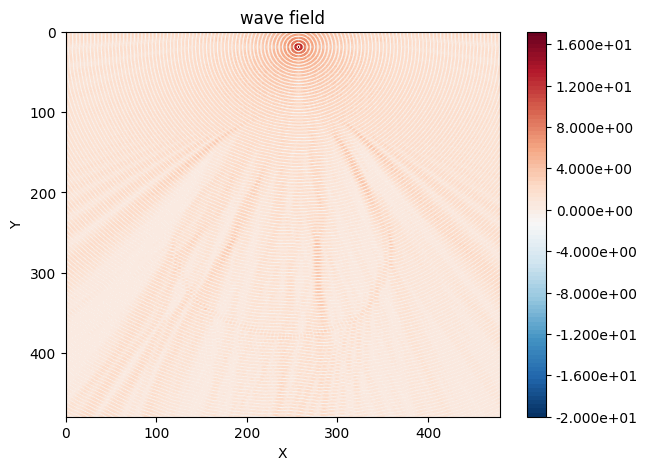

In [14]:
const = 10000

model_300k = ConvergentBornSeries(lamb = const/200,
                             sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
                             src_loc= [int(x_pos_down[0]),int(y_pos_down[0])],
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)

# model_400k = ConvergentBornSeries(lamb = const/266.66,
#                              sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
#                              src_loc=[int(x_pos_down[0]),int(y_pos_down[0])],
#                              boundary_width=[32,32],
#                              boundary_strength=1,
#                              boundary_type='PML3',
#                              device = config.device)

# model_500k = ConvergentBornSeries(lamb = const/333.33,
#                              sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
#                              src_loc= [int(x_pos_down[0]),int(y_pos_down[0])],
#                              boundary_width=[32,32],
#                              boundary_strength=1,
#                              boundary_type='PML3',
#                              device = config.device)

u_300k = model_300k(max_iters=500, requries_grad=False).detach().cpu()
# u_400k = model_400k(max_iters=500, requries_grad=False).detach().cpu()
# u_500k = model_500k(max_iters=500, requries_grad=False).detach().cpu()

plot2Dimage(x_end=torch.real(u_300k).size(0),
            y_end=torch.real(u_300k).size(1),
            f=torch.real(u_300k),
            title='wave field')

# plot2Dimage(x_end=torch.real(u_400k).size(0),
#             y_end=torch.real(u_400k).size(1),
#             f=torch.real(u_400k),
#             title='wave field')

# plot2Dimage(x_end=torch.real(u_500k).size(0),
#             y_end=torch.real(u_500k).size(1),
#             f=torch.real(u_500k),
#             title='wave field')


# Parallel Implementation for CBS 

In [6]:
class ConvergentBornSeries_Batch(nn.Module):
    def __init__(self,
                 lamb = 1,
                 sos=None,
                 boundary_width=[8,8],
                 boundary_strength=1,
                 boundary_type='PML3',
                 device = "cuda:0",
                 ):
        super().__init__()
        # Device
        self.device = device
        # # PDE params
        self.lamb = lamb
        self.omega0 = 2*torch.pi / self.lamb 
        
        # Discretization
        self.PPW = 4
        self.pixel_size = self.lamb / self.PPW 
        
        sos = torch.tensor(sos, dtype=torch.float32, requires_grad=True, device=device)
        self.sos = nn.Parameter(sos)
        self.N = torch.tensor(sos.size()).to(int)
        
        # Sources Location # later as input!
        
        # Boundary Padding
        self.boundary_widths = torch.tensor(boundary_width,dtype=int)
        self.boundary_strength = boundary_strength
        self.boundary_type = boundary_type
        self.set_grid()

        # V(x) Params
        self.k =  self.omega0/self.sos
        self.k0 = torch.sqrt((torch.max(self.k**2) + torch.min(self.k**2))/2).detach()
        
        # CBS Iteration Params
        self.k2_pad = self.set_boundary(self.k)
        self.epsilon = torch.max(torch.abs(self.k2_pad**2 - self.k0**2)).detach()
        self.g0 = 1/(self.px_range**2+self.py_range**2-self.k0**2 - 1.0j*self.epsilon).detach()
        
        self.V = self.k2_pad - self.k0**2 - 1.0j*self.epsilon
        self.gamma = 1.j/self.epsilon*self.V
    
    def forward(self, src_loc_batch, max_iters=5,tol=1e-16, requries_grad = False):
        # Set src_location and initial points
        self.batch_size = src_loc_batch.shape[0]
        self.src_batch = self.set_src_loc(src_loc_batch)
        self.u = torch.zeros(self.new_N[0],self.new_N[1]).to(self.device)
        self.u_batch = torch.stack([self.u] * self.batch_size, dim=0) 

        # For batch
        self.V = self.V.unsqueeze(0)
        self.g0 = self.g0.unsqueeze(0)
        self.gamma = self.gamma.unsqueeze(0)

        if requries_grad:
            for _ in range(max_iters):
                
                tmp1 = self.V * self.u_batch
                tmp1[:, self.roi[0][0]:self.roi[0][1], self.roi[1][0]:self.roi[1][1]] += self.src_batch

                tmp2 = (self.gamma) * (self.u_batch - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                self.u_batch = self.u_batch - tmp2
        else:
            with torch.no_grad():
                for _ in range(max_iters):

                    tmp1 = self.V * self.u_batch
                    tmp1[:, self.roi[0][0]:self.roi[0][1], self.roi[1][0]:self.roi[1][1]] += self.src_batch

                    tmp2 = (self.gamma) * (self.u_batch - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                    self.u_batch = self.u_batch - tmp2

        return self.u_batch[:, self.roi[0][0]:self.roi[0][1], self.roi[1][0]:self.roi[1][1]]

    def set_grid(self):
        # Set New Grid for FFT 
        self.new_N = (2**(torch.ceil(torch.log2(self.N + self.boundary_widths)))).to(int).to(self.device) # To improve FFT efficiency

        self.x_range = (torch.arange(self.new_N[0])*self.pixel_size).view(-1,1).to(self.device)
        self.y_range = (torch.arange(self.new_N[1])*self.pixel_size).to(self.device)
        self.px_range = 2*torch.pi*torch.fft.fftfreq(self.new_N[0],d=self.pixel_size).view(-1,1).to(self.device)
        self.py_range = (2*torch.pi*torch.fft.fftfreq(self.new_N[1],d=self.pixel_size)).to(self.device)
        
        # Set Inner Grid Indices
        self.roi_size = torch.tensor(self.sos.size()).to(self.device)
        self.Bl = torch.ceil((self.new_N - self.roi_size)/2).to(int)
        self.Br = torch.floor((self.new_N - self.roi_size)/2).to(int)
        self.roi = [[self.Bl[0],self.Bl[0]+self.roi_size[0]],
                    [self.Bl[1],self.Bl[1]+self.roi_size[1]]]
        
        self.Bmax = torch.max(self.Br)
        self.x = torch.cat((torch.arange(self.Bl[0], 0, -1), torch.zeros(self.roi_size[0]), torch.arange(1, self.Br[0] + 1))).view(-1,1)
        self.y = torch.cat((torch.arange(self.Bl[1], 0, -1), torch.zeros(self.roi_size[1]), torch.arange(1, self.Br[1] + 1)))
        self.dist = torch.sqrt(self.x**2 + self.y**2).to(self.device)

    def set_boundary(self, k):
        k_pad = F.pad(k.unsqueeze(0), (self.Bl[1], self.Br[1], self.Bl[0], self.Br[0]), mode='replicate').squeeze()
        
        k0 = torch.sqrt(torch.mean(k_pad**2))* self.pixel_size # k0 in 1/pixels
        c = self.boundary_strength*k0**2 / (2*k0)
        f_boundary_curve, _ = self.compute_leakage_and_boundary_curve(boundary_type=self.boundary_type,
                                                                            r=self.dist,
                                                                            Bmax=self.Bmax,
                                                                            c=c,
                                                                            k0=k0)
        
        k2_pad = k_pad ** 2 + (f_boundary_curve * self.omega0**2).detach()
        return k2_pad

    def compute_leakage_and_boundary_curve(self,boundary_type, r, Bmax, c, k0):
        if boundary_type == 'PML5': 
            f_boundary_curve = 1 / k0**2 * (c**7 * r**5 * (6.0 + (2.0j * k0 - c) * r)) / \
                (720 + 720 * c * r + 360 * c**2 * r**2 + 120 * c**3 * r**3 + 30 * c**4 * r**4 + 6 * c**5 * r**5 + c**6 * r**6)
            leakage = torch.exp(-c * Bmax) * (720 + 720 * c * Bmax + 360 * c**2 * Bmax**2 + 
                                            120 * c**3 * Bmax**3 + 30 * c**4 * Bmax**4 + 
                                            6 * c**5 * Bmax**5 + c**6 * Bmax**6) / 24
        elif boundary_type == 'PML4':  # 4th order smooth
            f_boundary_curve = 1 / k0**2 * (c**6 * r**4 * (5.0 + (2.0j * k0 - c) * r)) / \
                (120 + 120 * c * r + 60 * c**2 * r**2 + 20 * c**3 * r**3 + 5 * c**4 * r**4 + c**5 * r**5)
            leakage = torch.exp(-c * Bmax) * (120 + 120 * c * Bmax + 60 * c**2 * Bmax**2 + 
                                            20 * c**3 * Bmax**3 + 5 * c**4 * Bmax**4 + c**5 * Bmax**5) / 24
        elif boundary_type == 'PML3':  # 3rd order smooth
            f_boundary_curve = 1 / k0**2 * (c**5 * r**3 * (4.0 + (2.0j * k0 - c) * r)) / \
                (24 + 24 * c * r + 12 * c**2 * r**2 + 4 * c**3 * r**3 + c**4 * r**4)
            leakage = torch.exp(-c * Bmax) * (24 + 24 * c * Bmax + 12 * c**2 * Bmax**2 + 
                                            4 * c**3 * Bmax**3 + c**4 * Bmax**4) / 24
        elif boundary_type == 'PML2':  # 2nd order smooth
            f_boundary_curve = 1 / k0**2 * (c**4 * r**2 * (3.0 + (2.0j * k0 - c) * r)) / \
                (6 + 6 * c * r + 3 * c**2 * r**2 + c**3 * r**3)
            leakage = torch.exp(-c * Bmax) * (6 + 6 * c * Bmax + 3 * c**2 * Bmax**2 + c**3 * Bmax**3) / 6
        elif boundary_type == 'PML1':  # 1st order smooth
            f_boundary_curve = 1 / k0**2 * (c**3 * r * (2.0 + (2.0j * k0 - c) * r)) / \
                (2.0 + 2.0 * c * r + c**2 * r**2) / k0**2 # (divide by k0^2 to get relative e_r)
            leakage = torch.exp(-c * Bmax) * (2 + 2 * c * Bmax + c**2 * Bmax**2) / 2
        else:
            raise ValueError(f"Unknown boundary type: {boundary_type}")
        return f_boundary_curve, leakage
    
    def get_u(self):
        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]].detach().cpu()
    
    def set_src_loc(self, src_loc_batch = np.array([[30,60],[240,280]])):
        batch_size = src_loc_batch.shape[0]
        src = torch.zeros_like(self.sos).to(self.device)
        src_batch = torch.stack([src] * batch_size, dim=0)
        
        for i in range(batch_size):
            src_loc = src_loc_batch[i]
            src_batch[i][src_loc[0],src_loc[1]] = 1

        src_batch = nn.Parameter(src_batch, requires_grad = False)
        return src_batch

In [7]:
const = 10000

x_pos = loadmat('x_pos.mat')['x_pos256']
y_pos = loadmat('y_pos.mat')['y_pos256']

x_pos_down = x_pos[2::4]
y_pos_down = y_pos[2::4]

receiver_indices = torch.cat((torch.tensor(x_pos.astype(np.int64)), torch.tensor(y_pos.astype(np.int64))), dim = 1)
transmitter_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)

model_300k_batch = ConvergentBornSeries_Batch(lamb = const/200,
                             sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)

# model_400k_batch = ConvergentBornSeries_Batch(lamb = const/266.66,
#                              sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
#                              boundary_width= [32,32],
#                              boundary_strength= 1,
#                              boundary_type= 'PML3',
#                              device = config.device)
# model_500k_batch = ConvergentBornSeries_Batch(lamb = const/333.33,
#                              sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
#                              boundary_width= [32,32],
#                              boundary_strength= 1,
#                              boundary_type= 'PML3',
#                              device = config.device)

u_300k_batch = model_300k_batch(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu()
# u_400k_batch = model_400k_batch(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu()
# u_500k_batch = model_500k_batch(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu()

# plot2Dimage(x_end=torch.real(u_300k_batch[0] ).size(0),
#             y_end=torch.real(u_300k_batch[0] ).size(1),
#             f=torch.real(u_300k_batch[0]),
#             title='wave field')

# plot2Dimage(x_end=torch.real(u_400k_batch[0] ).size(0),
#             y_end=torch.real(u_400k_batch[0] ).size(1),
#             f=torch.real(u_400k_batch[0] ),
#             title='wave field')

# plot2Dimage(x_end=torch.real(u_500k_batch[0] ).size(0),
#             y_end=torch.real(u_500k_batch[0] ).size(1),
#             f=torch.real(u_500k_batch[0] ),
#             title='wave field')

NameError: name 'loadmat' is not defined

In [71]:
model_300k_batch_temp = ConvergentBornSeries_Batch(lamb = const/200,
                             sos= denormalize(speed_batch)[0,0].detach().cpu()/1500,# default homogenous
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)

u_300k_batch_temp = model_300k_batch_temp(src_loc_batch = transmitter_indices, max_iters=500, requries_grad= False).detach().cpu()

/tmp/ipykernel_3164699/3281916176.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sos = torch.tensor(sos, dtype=torch.float32, requires_grad=True, device=device)


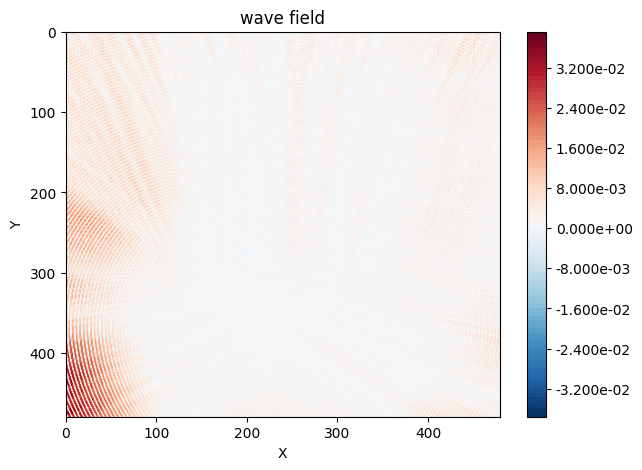

In [72]:
diff_300k_batch = u_300k_batch_temp - u_300k_batch

plot2Dimage(x_end=torch.real(diff_300k_batch[0]).size(0),
            y_end=torch.real(diff_300k_batch[0]).size(1),
            f=torch.real(diff_300k_batch[0]),
            title='wave field')

# Generate Data

In [52]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import os

x_pos = loadmat('x_pos.mat')['x_pos256']
y_pos = loadmat('y_pos.mat')['y_pos256']

x_pos_down = x_pos
y_pos_down = y_pos

receiver_indices = torch.cat((torch.tensor(x_pos.astype(np.int64)), torch.tensor(y_pos.astype(np.int64))), dim = 1)
transmitter_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)

speed_train_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/train"
speed_eval_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/eval"

dobs_300k_train_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/train"
dobs_300k_eval_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/eval"
dobs_400k_train_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/train"
dobs_400k_eval_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/eval"
dobs_500k_train_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/train"
dobs_500k_eval_path = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/eval"

In [ ]:
const = 10000

for count in range(6600):
    speed_train = np.load(os.path.join(speed_train_path, "train_"+str(count+1)+".npy"))

    model_300k = ConvergentBornSeries_Batch(lamb = const/200,
                             sos= torch.tensor(speed_train)/1500,
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)

    model_400k = ConvergentBornSeries_Batch(lamb = const/266.66,
                             sos= torch.tensor(speed_train)/1500,
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)

    model_500k = ConvergentBornSeries_Batch(lamb = const/333.33,
                             sos= torch.tensor(speed_train)/1500, 
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = config.device)
    
    u_300k = model_300k(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu().numpy()
    u_400k = model_400k(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu().numpy()
    u_500k = model_500k(src_loc_batch = transmitter_indices, max_iters=1500, requries_grad= False).detach().cpu().numpy()
        
    np.save(os.path.join(dobs_300k_train_path, "train_"+str(count+1)+ ".npy"), u_300k[:,receiver_indices[:,0], receiver_indices[:,1]])
    np.save(os.path.join(dobs_400k_train_path, "train_"+str(count+1)+ ".npy"), u_400k[:,receiver_indices[:,0], receiver_indices[:,1]])
    np.save(os.path.join(dobs_500k_train_path, "train_"+str(count+1)+ ".npy"), u_500k[:,receiver_indices[:,0], receiver_indices[:,1]])
    
    break

# DDIM + Gradient Descent

In [ ]:
from torch.utils.data import DataLoader
from my import MyDataset

x_pos = loadmat('x_pos.mat')['x_pos256']
y_pos = loadmat('y_pos.mat')['y_pos256']

x_pos_down = x_pos
y_pos_down = y_pos

receiver_indices = torch.cat((torch.tensor(x_pos.astype(np.int64)), torch.tensor(y_pos.astype(np.int64))), dim = 1)
transmitter_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)

file = {
    "use_mask": True,
    "deactivate_random": True,
    "noise_level": "free", 
    "mask": np.load("mask.npy"),
    "max_output" : 1595.1279, 
    "min_output" : 1408.692,
    "resize_size": (256,256), 
    "input_ratio": 1, 
    "output_background" : 0,
}

file["base_dir_dobs_300k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/train"
file["base_dir_dobs_400k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/train"
file["base_dir_dobs_500k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/train"
file["base_dir_dobs_300k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/eval"
file["base_dir_dobs_400k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/eval"
file["base_dir_dobs_500k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/eval"

file["base_dir_speed_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/train"
file["base_dir_speed_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/eval"

file["device"] = torch.device('cuda:5') if torch.cuda.is_available() else torch.device('cpu')

train_dataset = MyDataset(data_dict=file, mode="training", deactivate_random = file["deactivate_random"])
test_dataset = MyDataset(data_dict=file, mode="validation", deactivate_random = file["deactivate_random"])
training_set = DataLoader(train_dataset, batch_size = 64, shuffle=True, num_workers=8, pin_memory=True)
testing_set = DataLoader(test_dataset, batch_size= 1, shuffle=False, num_workers=1, pin_memory=True)

NameError: name 'loadmat' is not defined

# Testing! Optimize 10 db Noise Case without Diffusion

In [8]:
count = 200

input_batch, output_batch = test_dataset.__getitem__(count)
input_batch, output_batch = input_batch.unsqueeze(0), output_batch.unsqueeze(0).unsqueeze(0)
speed_batch, speed_5db_NIO_batch, speed_10db_NIO_batch, speed_free_NIO_batch = eval_dataset.__getitem__(count)
speed_NIO_batch = torch.cat([speed_free_NIO_batch, speed_10db_NIO_batch, speed_5db_NIO_batch], dim=0).unsqueeze(1)

const = 10000

model_300k_gt = ConvergentBornSeries_Batch(lamb = const/200,
                             sos= denormalize(output_batch)[0,0].detach().cpu()/1500,# default homogenous
                             boundary_width= [32,32],
                             boundary_strength= 1,
                             boundary_type= 'PML3',
                             device = file["device"])

u_300k_gt = model_300k_gt(src_loc_batch = transmitter_indices[0:1], max_iters=1500, requries_grad = False).detach().cpu()

NameError: name 'test_dataset' is not defined

In [93]:
model_300k_current = ConvergentBornSeries_Batch(lamb = const/200,
                                sos= denormalize(speed_NIO_batch)[0,0].detach().cpu()/1500,# default homogenous
                                #sos= denormalize(speed_batch.unsqueeze(0))[0,0].detach().cpu()/1500,# default homogenous
                                boundary_width= [32,32],
                                boundary_strength= 1,
                                boundary_type= 'PML3',
                                device = file["device"])

u_300k_current = model_300k_current(src_loc_batch = transmitter_indices[0:1], max_iters=500, requries_grad = False).detach().cpu()

/tmp/ipykernel_3164699/3281916176.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sos = torch.tensor(sos, dtype=torch.float32, requires_grad=True, device=device)


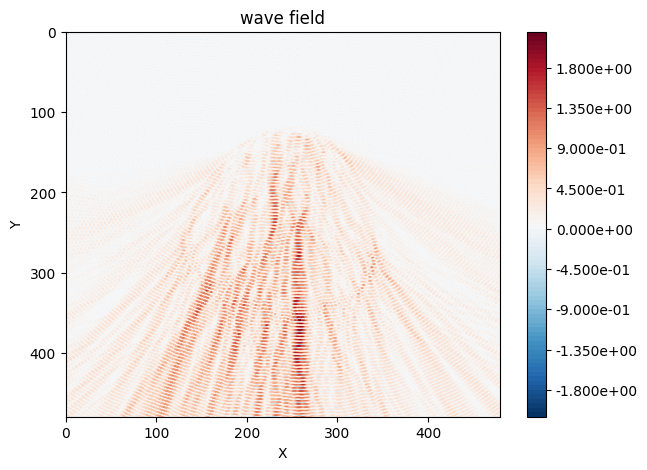

In [94]:
idx = 0
diff_300k_batch = u_300k_current - u_300k_gt
plot2Dimage(x_end=torch.real(diff_300k_batch[0]).size(0),
            y_end=torch.real(diff_300k_batch[0]).size(1),
            f=torch.real(diff_300k_batch[0]),
            title='wave field')

# 要及时删除 GPU 上的变量 不然一直占用就无法 del 
# del model_300k_current
# del model_300k_gt
# del u_300k_current
# del u_300k_gt

# torch.cuda.empty_cache()

In [98]:
import random
num_epoch, const = 10, 10000
speed_current = denormalize(speed_NIO_batch)[1,0].to(file["device"])/1500
#speed_current = denormalize(speed_NIO_batch)[1,0].to(file["device"])/1500

for epoch in range(num_epoch):
    random_batch_list = random.sample(range(0, 256), 16) 
    partial_indices = transmitter_indices[random_batch_list,:] # partial transmitters 
    random_mask = torch.tensor(file["mask"][random_batch_list]).to(file["device"]) # masked receivers

    random_number = random.random()
    if random_number < 0.9999:
        print("300k")
        model_current = ConvergentBornSeries_Batch(lamb = const/200,
                                sos = speed_current, 
                                boundary_width = [32,32],
                                boundary_strength = 1,
                                boundary_type = 'PML3',
                                device = file["device"])
        u_data_gt = input_batch[0,0:2,:,:][:,random_batch_list,:].to(file["device"])

    elif random_number < 1:
        print("400k")
        model_current = ConvergentBornSeries_Batch(lamb = const/266.66,
                                sos= speed_current, 
                                boundary_width= [32,32],
                                boundary_strength= 1,
                                boundary_type= 'PML3',
                                device = file["device"])
        u_data_gt = input_batch[0,2:4,:,:][:,random_batch_list,:].to(file["device"])

    else:
        print("500k")
        model_current = ConvergentBornSeries_Batch(lamb = const/333.33,
                                sos= speed_current,
                                boundary_width=[32,32],
                                boundary_strength=1,
                                boundary_type='PML3',
                                device = file["device"])
        u_data_gt = input_batch[0,4:6,:,:][:,random_batch_list,:].to(file["device"])
    

    u_current = model_current(src_loc_batch = partial_indices, max_iters=500, requries_grad = True)
    u_pred = u_current[:,receiver_indices[:,0], receiver_indices[:,1]]
    u_pred = torch.view_as_real(u_pred).permute(2,0,1) * random_mask
    
    criterion = RelL2Loss()
    
    loss = criterion(u_data_gt, u_pred)
    loss.backward()
    speed_current[90:390,90:390] -= 0.2 * model_current.sos.grad[90:390,90:390]
    
    print(loss)


300k


/tmp/ipykernel_3164699/3281916176.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sos = torch.tensor(sos, dtype=torch.float32, requires_grad=True, device=device)


tensor(0.3935, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.3377, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.3143, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.3206, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.3035, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.2839, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.2828, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.2818, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.2653, device='cuda:5', grad_fn=<MeanBackward0>)
300k
tensor(0.2582, device='cuda:5', grad_fn=<MeanBackward0>)


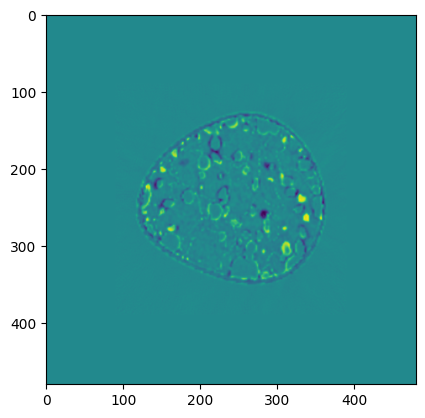

In [105]:
plt.imshow(speed_current.detach().cpu() - denormalize(speed_batch.unsqueeze(0))[0,0].to(file["device"]).cpu()/1500)

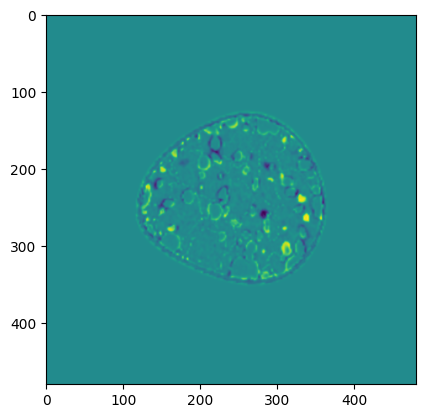

In [106]:
plt.imshow(denormalize(speed_NIO_batch)[1,0].to(file["device"]).cpu()/1500 - denormalize(speed_batch.unsqueeze(0))[0,0].to(file["device"]).cpu()/1500)

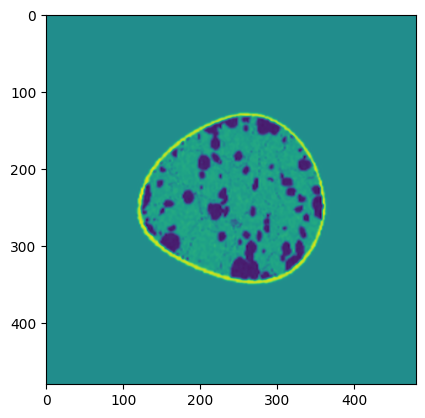

In [253]:
plt.imshow(denormalize(speed_batch.unsqueeze(0))[0,0].to(file["device"]).cpu()/1500)

In [ ]:
#装载图片
def log_image_cbs(path, field, pred_field, min_output=1408.692, max_output=1595.1279):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 用于确保统一的colorbar范围
    vmin, vmax = min_output, max_output

    # 显示第一个图像 field
    im1 = axes[0].imshow(field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("Field")
    fig.colorbar(im1, ax=axes[0])

    # 显示第二个图像 pred_field
    im2 = axes[1].imshow(pred_field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("Free Predicted field")
    fig.colorbar(im2, ax=axes[1])

    im3 = axes[2].imshow(pred_field[1, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("10db Predicted Field")
    fig.colorbar(im3, ax=axes[2])

    im4 = axes[3].imshow(pred_field[2, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[3].set_title("5db Predicted Field")
    fig.colorbar(im4, ax=axes[3])

    # 调整布局并保存图像
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()